In [41]:
import sympy as sp
import numpy as np
import dg_geometry as DG503

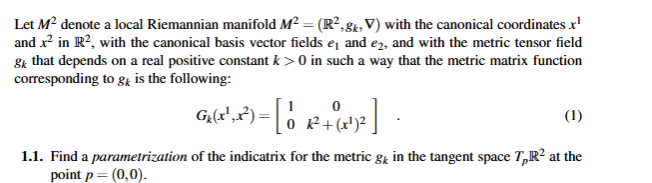

In [42]:
x1, x2, t, k, f, h = sp.symbols('x1 x2 t k f h', real=True)

Gk = sp.Matrix([[1, 0], [0, k**2 + x1**2]])
display(Gk)

Gk_0 = Gk.subs(x1, 0).subs(x2, 0)

V = sp.Matrix([f, h])

I = DG503.g_dot(Gk_0, V, V)
display(I)

V = sp.Matrix([sp.cos(t), sp.sin(t)/k])
display(V)

I = DG503.g_dot(Gk_0, V, V)
display(I)

Matrix([
[1,            0],
[0, k**2 + x1**2]])

f**2 + h**2*k**2

Matrix([
[  cos(t)],
[sin(t)/k]])

1

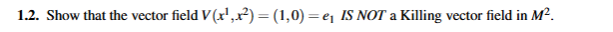

In [43]:
coords = sp.Matrix([x1,x2])

V = sp.Matrix([1, 0])

Lv_g = DG503.lie_derivative_metric(Gk, V, coords)

display(Lv_g)

Matrix([
[0,    0],
[0, 2*x1]])

In [44]:
W = sp.Matrix([0, 1])

Lw_g = DG503.lie_derivative_metric(Gk, W, coords)

display(Lw_g)

Matrix([
[0, 0],
[0, 0]])

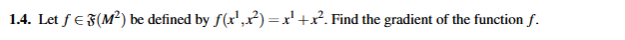

In [45]:
f = x1 + x2

grad_f = DG503.gradient(Gk, f, coords)
display(grad_f)

Matrix([
[               1],
[1/(k**2 + x1**2)]])

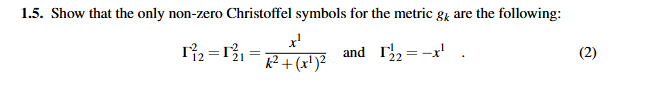

In [46]:
DG503.christoffel_symbols(Gk, coords)


{(0, 0, 0): 0,
 (0, 0, 1): 0,
 (0, 1, 0): 0,
 (0, 1, 1): x1/(k**2 + x1**2),
 (1, 0, 0): 0,
 (1, 0, 1): x1/(k**2 + x1**2),
 (1, 1, 0): -x1,
 (1, 1, 1): 0}

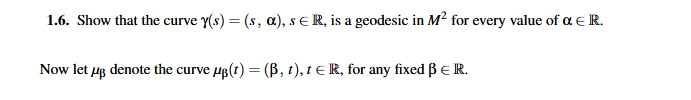

In [47]:
s, alpha = sp.symbols('s alpha', real=True)

gamma = sp.Matrix([s, alpha])

acc = DG503.curve_acceleration(Gk, gamma, s, coords)

display(acc)

Matrix([
[0],
[0]])

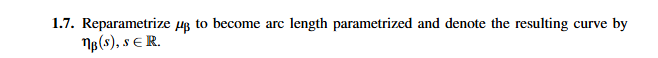

In [60]:
beta, t, tau = sp.symbols('beta t tau', real=True)

mu_beta = sp.Matrix([[beta], [t]])
mu_beta_dot = sp.diff(mu_beta, t)
display(Gk.subs(x1,beta))

mu_beta_dot = DG503.g_norm(Gk.subs(x1,beta), mu_beta_dot)
display(mu_beta_dot)

arc_length = sp.integrate(mu_beta_dot, (tau, 0, t))
display(arc_length)

solved_arc_length_s = sp.solve(sp.Eq(arc_length, s), t)[0]
display(solved_arc_length_s)

mu_beta_s = sp.Matrix([[beta], [solved_arc_length_s]])
display(mu_beta_s)

Matrix([
[1,              0],
[0, beta**2 + k**2]])

sqrt(beta**2 + k**2)

t*sqrt(beta**2 + k**2)

s/sqrt(beta**2 + k**2)

Matrix([
[                  beta],
[s/sqrt(beta**2 + k**2)]])

In [62]:
x1, x2, k, beta, k = sp.symbols('x1 x2 k beta k', real=True) 

Gk = sp.Matrix([[1, 0], [0, k**2 + x1**2]])
display(Gk)

coords = sp.Matrix([x1, x2])

acc = DG503.curve_acceleration(Gk, mu_beta_s, s, coords)
display(acc)

Matrix([
[1,            0],
[0, k**2 + x1**2]])

Matrix([
[-beta/(beta**2 + k**2)],
[                     0]])

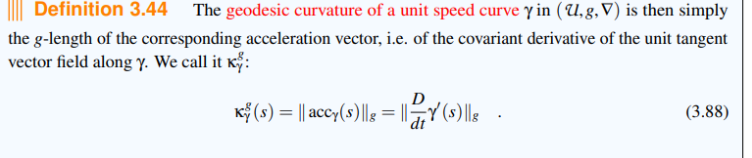

If beta is 0 the acceleration is 0

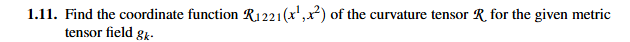

In [64]:
curv_tens = DG503.curvature_tensor(Gk, coords)
display(curv_tens[0,1,1,0])

-k**2/(k**2 + x1**2)

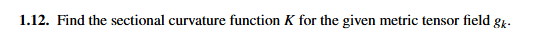

In [66]:
point = sp.Matrix([x1, x2])
V = sp.Matrix([1, 0])
W = sp.Matrix([0, 1])

sec_curv = DG503.sectional_curvature(Gk, point, V, W, coords)
display(sec_curv)

-k**2/(k**2 + x1**2)**2

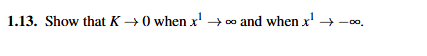

In [68]:
K_x1_inf = sp.limit(sec_curv, x1, sp.oo)
display(K_x1_inf)
K_x1_neg_inf = sp.limit(sec_curv, x1, -sp.oo)
display(K_x1_neg_inf)

0

0

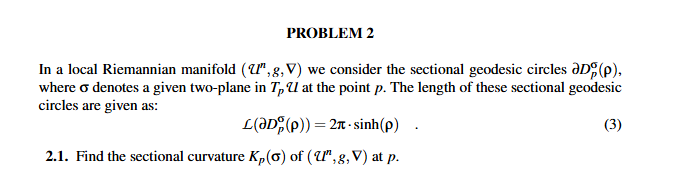

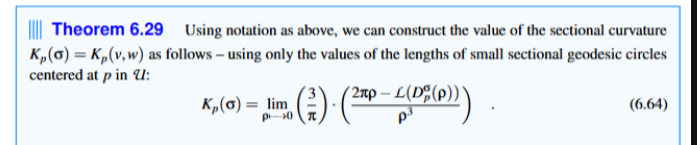

In [71]:
rho = sp.symbols('rho', real=True)

L = 2*sp.pi*sp.sinh(rho)

K_p = 3/(sp.pi)*sp.limit((2*sp.pi*rho-L)/rho**3, rho, 0)

display(K_p)

-1

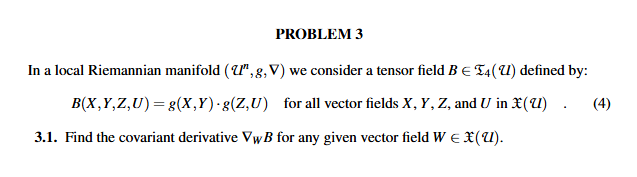

We use 7.19

$ (\nabla_W B)(X, Y, Z, U) = W(B(X, Y, Z, U)) - B(\nabla_W X, Y, Z, U) $ 

$ B(X, \nabla_W Y, Z, U) - B(X, Y, \nabla_W Z, U) - B(X, Y, Z, \nabla_W U) $

We can then input them into the metrics starting with the first term

$(\nabla_W B)(X, Y, Z, U) = W(g(X,Y) \cdot g(Z,U)) =$ 

$W(g(X,Y)) \cdot g(Z,U) + g(X,Y) \cdot W(g(Z,U)) =$ 

$g(Z,U) \cdot (g(\nabla_W X,Y) + g(X,\nabla_W Y))  + g(X,Y) \cdot (g(\nabla_W Z,U) + g(Z,\nabla_W U) )$ 

And the rest of the terms become

$B(\nabla_W X, Y, Z, U) = g(\nabla_W X, Y)g(Z, U)$

$B(X, \nabla_W Y, Z, U) = g(X, \nabla_W Y)g(Z, U)$

$B(X, Y, \nabla_W Z, U) = g(X, Y)g(\nabla_W Z, U)$

$B(X, Y, Z, \nabla_W U) = g(X, Y)g(Z, \nabla_W U)$

We can now see that they all cancel out and become

$\nabla_W B = 0$